## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Cài đặt thư viện cần thiết

In [ ]:
!pip install mediapipe opencv-python tensorflow matplotlib seaborn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 9.5 MB/s eta 0:00:00

## 3. Import thư viện

In [ ]:
import numpy as np
import tensorflow as tf
import os
import cv2
import mediapipe as mp
from scipy.interpolate import interp1d
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# Set style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


## 4. Cấu hình đường dẫn

In [ ]:
# Đường dẫn gốc của project trên Google Drive
BASE_PATH = '/content/drive/MyDrive/VSL_Data/Phuong'

# Đường dẫn đến model và label map
MODEL_PATH = os.path.join(BASE_PATH, 'Models/checkpoints/final_model.keras')
LABEL_MAP_PATH = os.path.join(BASE_PATH, 'Logs/label_map.json')

# Đường dẫn đến thư mục chứa video test (THAY ĐỔI ĐỂ TRỎ ĐẾN THỦ MỤC VIDEO TEST CỦA BẠN)
TEST_VIDEO_DIR = os.path.join(BASE_PATH, 'Test_Videos')

# Đường dẫn đến file label.csv (chứa mapping nhãn -> video gốc)
LABEL_CSV_PATH = os.path.join(BASE_PATH, 'Dataset/Text/label.csv')

print("=" * 80)
print("🔧 CẤU HÌNH ĐƯỜNG DẪN".center(80))
print("=" * 80)
print(f"\n📂 Base path: {BASE_PATH}")
print(f"🤖 Model: {MODEL_PATH}")
print(f"🏷️  Label map: {LABEL_MAP_PATH}")
print(f"📊 Label CSV: {LABEL_CSV_PATH}")
print(f"🎥 Test videos: {TEST_VIDEO_DIR}")
print("\n" + "=" * 80)
print(f"💡 Lưu ý: Đặt video test vào thư mục: {TEST_VIDEO_DIR}")
print("=" * 80)

                              🔧 CẤU HÌNH ĐƯỜNG DẪN                              

📂 Base path: /content/drive/MyDrive/VSL_Data/Phuong
🤖 Model: /content/drive/MyDrive/VSL_Data/Phuong/Models/checkpoints/final_model.keras
🏷️  Label map: /content/drive/MyDrive/VSL_Data/Phuong/Logs/label_map.json
📊 Label CSV: /content/drive/MyDrive/VSL_Data/Phuong/Dataset/Text/label.csv
🎥 Test videos: /content/drive/MyDrive/VSL_Data/Phuong/Test_Videos

💡 Lưu ý: Đặt video test vào thư mục: /content/drive/MyDrive/VSL_Data/Phuong/Test_Videos


## 5. Định nghĩa constants

In [ ]:
# Mediapipe constants
mp_holistic = mp.solutions.holistic
N_UPPER_BODY_POSE_LANDMARKS = 25
N_HAND_LANDMARKS = 21
N_TOTAL_LANDMARKS = N_UPPER_BODY_POSE_LANDMARKS + N_HAND_LANDMARKS + N_HAND_LANDMARKS

print(f"Total landmarks: {N_TOTAL_LANDMARKS}")

Total landmarks: 67


## 6. Load model và label map

In [ ]:
print("=" * 80)
print("📥 LOADING MODEL & DATA".center(80))
print("=" * 80)

# Load model
print("\n⏳ Loading model...")
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded!")
print(f"   Input shape: {model.input_shape}")
print(f"   Output shape: {model.output_shape}")

# Load label map
print("\n⏳ Loading label map...")
with open(LABEL_MAP_PATH, 'r', encoding='utf-8') as f:
    label_map = json.load(f)

# Tạo inverse label map (index -> label)
inv_label_map = {v: k for k, v in label_map.items()}
print(f"✅ Label map loaded! ({len(label_map)} labels)")

# Load label.csv để mapping nhãn -> video gốc
print("\n⏳ Loading label.csv...")
df_label = pd.read_csv(LABEL_CSV_PATH, encoding='utf-8')

# Tạo mapping: nhãn -> danh sách video gốc
label_to_videos = {}
for label in df_label['LABEL'].unique():
    videos = df_label[df_label['LABEL'] == label]['VIDEO'].tolist()
    # Lấy 3 video đầu tiên để hiển thị (tránh quá dài)
    label_to_videos[label] = videos[:3]

print(f"✅ Label CSV loaded! ({len(label_to_videos)} unique labels)")
print("\n" + "=" * 80)

                             📥 LOADING MODEL & DATA                             

⏳ Loading model...
✅ Model loaded!
   Input shape: (None, 60, 201)
   Output shape: (None, 2764)

⏳ Loading label map...
✅ Label map loaded! (2764 labels)

⏳ Loading label.csv...
✅ Label CSV loaded! (2877 unique labels)



## 7. Định nghĩa các hàm xử lý video

In [ ]:
def mediapipe_detection(image, model):
    """Xử lý frame bằng Mediapipe để phát hiện landmarks"""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results


def extract_keypoints(results):
    """Trích xuất keypoints từ kết quả Mediapipe"""
    pose_kps = np.zeros((N_UPPER_BODY_POSE_LANDMARKS, 3))
    left_hand_kps = np.zeros((N_HAND_LANDMARKS, 3))
    right_hand_kps = np.zeros((N_HAND_LANDMARKS, 3))

    if results and results.pose_landmarks:
        for i in range(N_UPPER_BODY_POSE_LANDMARKS):
            if i < len(results.pose_landmarks.landmark):
                res = results.pose_landmarks.landmark[i]
                pose_kps[i] = [res.x, res.y, res.z]

    if results and results.left_hand_landmarks:
        left_hand_kps = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark])

    if results and results.right_hand_landmarks:
        right_hand_kps = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark])

    keypoints = np.concatenate([pose_kps, left_hand_kps, right_hand_kps])
    return keypoints.flatten()


def interpolate_keypoints(keypoints_sequence, target_len=60):
    """Nội suy chuỗi keypoints về 60 frames"""
    if len(keypoints_sequence) == 0:
        return None

    original_times = np.linspace(0, 1, len(keypoints_sequence))
    target_times = np.linspace(0, 1, target_len)

    num_features = keypoints_sequence[0].shape[0]
    interpolated_sequence = np.zeros((target_len, num_features))

    for feature_idx in range(num_features):
        feature_values = [frame[feature_idx] for frame in keypoints_sequence]
        interpolator = interp1d(
            original_times, feature_values,
            kind='cubic',
            bounds_error=False,
            fill_value="extrapolate"
        )
        interpolated_sequence[:, feature_idx] = interpolator(target_times)

    return interpolated_sequence


def sequence_frames(video_path, holistic):
    """Trích xuất sequence keypoints từ video"""
    sequence_frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    step = max(1, total_frames // 100)  # Lấy mẫu frames

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if int(cap.get(cv2.CAP_PROP_POS_FRAMES)) % step != 0:
            continue

        try:
            image, results = mediapipe_detection(frame, holistic)
            keypoints = extract_keypoints(results)

            if keypoints is not None:
                sequence_frames.append(keypoints)
        except Exception as e:
            continue

    cap.release()
    return sequence_frames

print("✅ Các hàm xử lý video đã được định nghĩa!")

✅ Các hàm xử lý video đã được định nghĩa!


## 8. Hàm dự đoán và hiển thị top 5

In [ ]:
def predict_video(video_path, holistic, model, inv_label_map, top_k=5):
    """
    Dự đoán video và trả về top K predictions

    Returns:
        dict: {
            'top1_label': str,
            'top1_confidence': float,
            'top_k_results': [(label, confidence), ...]
        }
    """
    try:
        # Trích xuất keypoints từ video
        sequence = sequence_frames(video_path, holistic)

        if len(sequence) == 0:
            return None

        # Nội suy về 60 frames
        kp = interpolate_keypoints(sequence)

        if kp is None:
            return None

        # Dự đoán
        result = model.predict(np.expand_dims(kp, axis=0), verbose=0)
        probabilities = result[0]

        # Lấy top K predictions
        top_k_indices = np.argsort(probabilities)[::-1][:top_k]
        top_k_results = [(inv_label_map[idx], float(probabilities[idx] * 100))
                        for idx in top_k_indices]

        return {
            'top1_label': top_k_results[0][0],
            'top1_confidence': top_k_results[0][1],
            'top_k_results': top_k_results
        }
    except Exception as e:
        print(f"❌ Lỗi khi xử lý video {video_path}: {e}")
        return None


def plot_top5_bar(top_k_results, title="Top 5 Predictions"):
    """Vẽ biểu đồ cột cho top 5 predictions"""
    labels = [item[0] for item in top_k_results]
    confidences = [item[1] for item in top_k_results]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette("husl", len(labels))
    bars = ax.barh(labels, confidences, color=colors)

    # Thêm giá trị vào mỗi cột
    for i, (bar, conf) in enumerate(zip(bars, confidences)):
        ax.text(conf + 1, i, f'{conf:.2f}%', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Label', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 100)

    plt.tight_layout()
    plt.show()

print("✅ Các hàm dự đoán đã được định nghĩa!")

✅ Các hàm dự đoán đã được định nghĩa!


## 10. Test hàng loạt video trong thư mục

In [ ]:
print("=" * 80)
print("🔍 SCANNING VIDEO FILES".center(80))
print("=" * 80)

# Lấy danh sách tất cả video trong thư mục
video_extensions = ['.mp4', '.avi', '.mov', '.mkv']
video_files = []

for ext in video_extensions:
    video_files.extend(Path(TEST_VIDEO_DIR).rglob(f'*{ext}'))

print(f"\n📊 Tìm thấy {len(video_files)} video files")

if len(video_files) > 0:
    print("\n📋 Danh sách video:")
    for i, vf in enumerate(video_files[:15], 1):  # Hiển thị 15 video đầu
        print(f"   {i:2d}. {vf.name}")
    if len(video_files) > 15:
        print(f"   ... và {len(video_files) - 15} video khác")
else:
    print(f"\n⚠️  Không tìm thấy video nào!")
    print(f"💡 Kiểm tra lại: {TEST_VIDEO_DIR}")

print("\n" + "=" * 80)

                             🔍 SCANNING VIDEO FILES                             

📊 Tìm thấy 8 video files

📋 Danh sách video:
    1. Bản sao của W04035.mp4
    2. Bản sao của W04013.mp4
    3. Bản sao của W04025N.mp4
    4. Bản sao của W04071.mp4
    5. Bản sao của W04057T.mp4
    6. Bản sao của W03962B.mp4
    7. Bản sao của W04073.mp4
    8. Bản sao của D0007.mp4



In [ ]:
# Test hàng loạt tất cả video
if len(video_files) > 0:
    print("=" * 80)
    print("🚀 BẮT ĐẦU BATCH TESTING".center(80))
    print("=" * 80)

    results_list = []

    # Khởi tạo Mediapipe Holistic
    holistic = mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5)

    print(f"\n⏳ Đang xử lý {len(video_files)} videos...\n")

    for video_path in tqdm(video_files, desc="🎬 Processing", unit="video"):
        video_name = video_path.name

        prediction = predict_video(str(video_path), holistic, model, inv_label_map, top_k=5)

        if prediction:
            results_list.append({
                'video_name': video_name,
                'top1_label': prediction['top1_label'],
                'top1_confidence': prediction['top1_confidence'],
                'top2_label': prediction['top_k_results'][1][0] if len(prediction['top_k_results']) > 1 else '',
                'top2_confidence': prediction['top_k_results'][1][1] if len(prediction['top_k_results']) > 1 else 0,
                'top3_label': prediction['top_k_results'][2][0] if len(prediction['top_k_results']) > 2 else '',
                'top3_confidence': prediction['top_k_results'][2][1] if len(prediction['top_k_results']) > 2 else 0,
                'top4_label': prediction['top_k_results'][3][0] if len(prediction['top_k_results']) > 3 else '',
                'top4_confidence': prediction['top_k_results'][3][1] if len(prediction['top_k_results']) > 3 else 0,
                'top5_label': prediction['top_k_results'][4][0] if len(prediction['top_k_results']) > 4 else '',
                'top5_confidence': prediction['top_k_results'][4][1] if len(prediction['top_k_results']) > 4 else 0,
            })
        else:
            results_list.append({
                'video_name': video_name,
                'top1_label': 'ERROR',
                'top1_confidence': 0,
                'top2_label': '', 'top2_confidence': 0,
                'top3_label': '', 'top3_confidence': 0,
                'top4_label': '', 'top4_confidence': 0,
                'top5_label': '', 'top5_confidence': 0,
            })

    # Tạo DataFrame
    df_results = pd.DataFrame(results_list)

    # Lọc kết quả hợp lệ ngay sau khi test xong
    df_valid = df_results[df_results['top1_label'] != 'ERROR'].copy()

    print("\n" + "=" * 80)
    print("✅ HOÀN THÀNH BATCH TESTING!".center(80))
    print("=" * 80)
    print(f"\n📊 Tổng quan:")
    print(f"   ✓ Thành công: {len(df_valid)}/{len(df_results)} videos ({len(df_valid)/len(df_results)*100:.1f}%)")
    print(f"   ✗ Lỗi: {len(df_results) - len(df_valid)} videos")
    print("\n" + "=" * 80)
else:
    print("⚠️  Không có video để test")

                            🚀 BẮT ĐẦU BATCH TESTING                             

⏳ Đang xử lý 8 videos...



🎬 Processing: 100%|██████████| 8/8 [01:32<00:00, 11.51s/video]


                          ✅ HOÀN THÀNH BATCH TESTING!                           

📊 Tổng quan:
   ✓ Thành công: 8/8 videos (100.0%)
   ✗ Lỗi: 0 videos



## 11. Hiển thị kết quả dạng bảng

In [ ]:
if len(video_files) > 0 and len(results_list) > 0:
    print("=" * 80)
    print("📋 KẾT QUẢ DỰ ĐOÁN".center(80))
    print("=" * 80)

    # Hàm format gọn: hiển thị 1 video training cạnh nhãn
    def format_label_inline(label):
        if not label or label == 'ERROR':
            return label
        videos = label_to_videos.get(label, [])
        if videos:
            return f"{label} ({videos[0]})"  # chỉ hiển thị video đầu tiên
        return label

    # Tạo bảng hiển thị rút gọn (Top 3 cho mỗi video)
    df_display = df_results[['video_name', 'top1_label', 'top1_confidence',
                             'top2_label', 'top2_confidence',
                             'top3_label', 'top3_confidence']].copy()

    # Format cho hiển thị console (hiển thị kèm 1 video train kế bên nhãn)
    df_console = df_display.copy()
    df_console['Top 1'] = df_console.apply(
        lambda x: f"{format_label_inline(x['top1_label'])} ({x['top1_confidence']:.1f}%)" if x['top1_label'] != 'ERROR' else 'ERROR',
        axis=1
    )
    df_console['Top 2'] = df_console.apply(
        lambda x: f"{format_label_inline(x['top2_label'])} ({x['top2_confidence']:.1f}%)" if x['top2_label'] else '',
        axis=1
    )
    df_console['Top 3'] = df_console.apply(
        lambda x: f"{format_label_inline(x['top3_label'])} ({x['top3_confidence']:.1f}%)" if x['top3_label'] else '',
        axis=1
    )

    # Hiển thị bảng rút gọn
    print("\n📊 Bảng kết quả (Top 3):")
    print("-" * 80)

    # Chỉ hiển thị các cột cần thiết
    display_df = df_console[['video_name', 'Top 1', 'Top 2', 'Top 3']]
    display_df.columns = ['Video', 'Top 1 (nhãn + 1 video train)', 'Top 2', 'Top 3']

    # Set pandas options tạm thời
    with pd.option_context('display.max_rows', None,
                          'display.max_columns', None,
                          'display.width', 1000,
                          'display.max_colwidth', 120):
        print(display_df.to_string(index=False))

    # Giải thích ngắn
    print("\n💡 Chú thích:")
    print("   - Hiển thị gọn: Nhãn (tên 1 video training tiêu biểu)")
    print("   - Mục tiêu: gọn nhất có thể nhưng vẫn đủ ngữ cảnh để debug")
    print("=" * 80)

                               📋 KẾT QUẢ DỰ ĐOÁN                                

📊 Bảng kết quả (Top 3):
--------------------------------------------------------------------------------
                    Video         Top 1 (nhãn + 1 video train)                         Top 2                           Top 3
 Bản sao của W04035.mp4          ý chí (W04035.mp4) (100.0%)       uốn (W03745.mp4) (0.0%)                     y tế (0.0%)
 Bản sao của W04013.mp4         xúc xắc (W04013.mp4) (99.7%) giai đoạn (W01423.mp4) (0.2%)   gương mẫu (W01525.mp4) (0.0%)
Bản sao của W04025N.mp4          bé gái (W00217.mp4) (99.7%)                giận dữ (0.2%)      mặc kệ (W02159.mp4) (0.1%)
 Bản sao của W04071.mp4          đắt đỏ (W01131.mp4) (99.2%)   hung ác (W01711.mp4) (0.7%)      ai bảo (W04071.mp4) (0.1%)
Bản sao của W04057T.mp4          gốm sứ (W01517.mp4) (61.2%)                   sáo (21.1%)     cơ quan (W00870.mp4) (6.4%)
Bản sao của W03962B.mp4         đôi tay (W01274.mp4) (81.3%) 

## 12. Thống kê và biểu đồ tổng quan

In [ ]:
if len(video_files) > 0 and len(results_list) > 0 and len(df_valid) > 0:
    print("=" * 80)
    print("📊 THỐNG KÊ TỔNG QUAN".center(80))
    print("=" * 80)

    # Thống kê các label được dự đoán
    label_counts = df_valid['top1_label'].value_counts()

    print("\n🏆 Top 10 nhãn được dự đoán nhiều nhất:")
    print("-" * 80)
    for i, (label, count) in enumerate(label_counts.head(10).items(), 1):
        percentage = count/len(df_valid)*100
        bar = "█" * int(percentage / 2)  # Simple bar chart
        print(f"  {i:2d}. {label:<25} {bar:<50} {count} ({percentage:.1f}%)")

    # Thống kê confidence
    print("\n📈 Thống kê Confidence (Top 1):")
    print("-" * 80)
    print(f"  {'Trung bình:':<15} {df_valid['top1_confidence'].mean():>6.2f}%")
    print(f"  {'Cao nhất:':<15} {df_valid['top1_confidence'].max():>6.2f}%")
    print(f"  {'Thấp nhất:':<15} {df_valid['top1_confidence'].min():>6.2f}%")
    print(f"  {'Trung vị:':<15} {df_valid['top1_confidence'].median():>6.2f}%")
    print(f"  {'Độ lệch chuẩn:':<15} {df_valid['top1_confidence'].std():>6.2f}%")

    print("\n" + "=" * 80)
elif len(video_files) > 0 and len(results_list) > 0:
    print("\n⚠️  Không có kết quả hợp lệ để thống kê (tất cả đều lỗi)")
    print("=" * 80)

                              📊 THỐNG KÊ TỔNG QUAN                              

🏆 Top 10 nhãn được dự đoán nhiều nhất:
--------------------------------------------------------------------------------
   1. ý chí                     ██████                                             1 (12.5%)
   2. xúc xắc                   ██████                                             1 (12.5%)
   3. bé gái                    ██████                                             1 (12.5%)
   4. đắt đỏ                    ██████                                             1 (12.5%)
   5. gốm sứ                    ██████                                             1 (12.5%)
   6. đôi tay                   ██████                                             1 (12.5%)
   7. ngôn ngữ kí hiệu          ██████                                             1 (12.5%)
   8. khoá (cái khóa)           ██████                                             1 (12.5%)

📈 Thống kê Confidence (Top 1):
----------------------

📊 Biểu đồ phân bố chi tiết:


/tmp/ipython-input-3203875684.py:50: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3203875684.py:50: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3203875684.py:50: UserWarning: Glyph 7907 (\N{LATIN SMALL LETTER O WITH HORN AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3203875684.py:50: UserWarning: Glyph 7855 (\N{LATIN SMALL LETTER A WITH BREVE AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3203875684.py:50: UserWarning: Glyph 7887 (\N{LATIN SMALL LETTER O WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3203875684.py:50: UserWarning: Glyph 7913 (\N{LATIN SMALL LETTER U WITH HORN AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/t

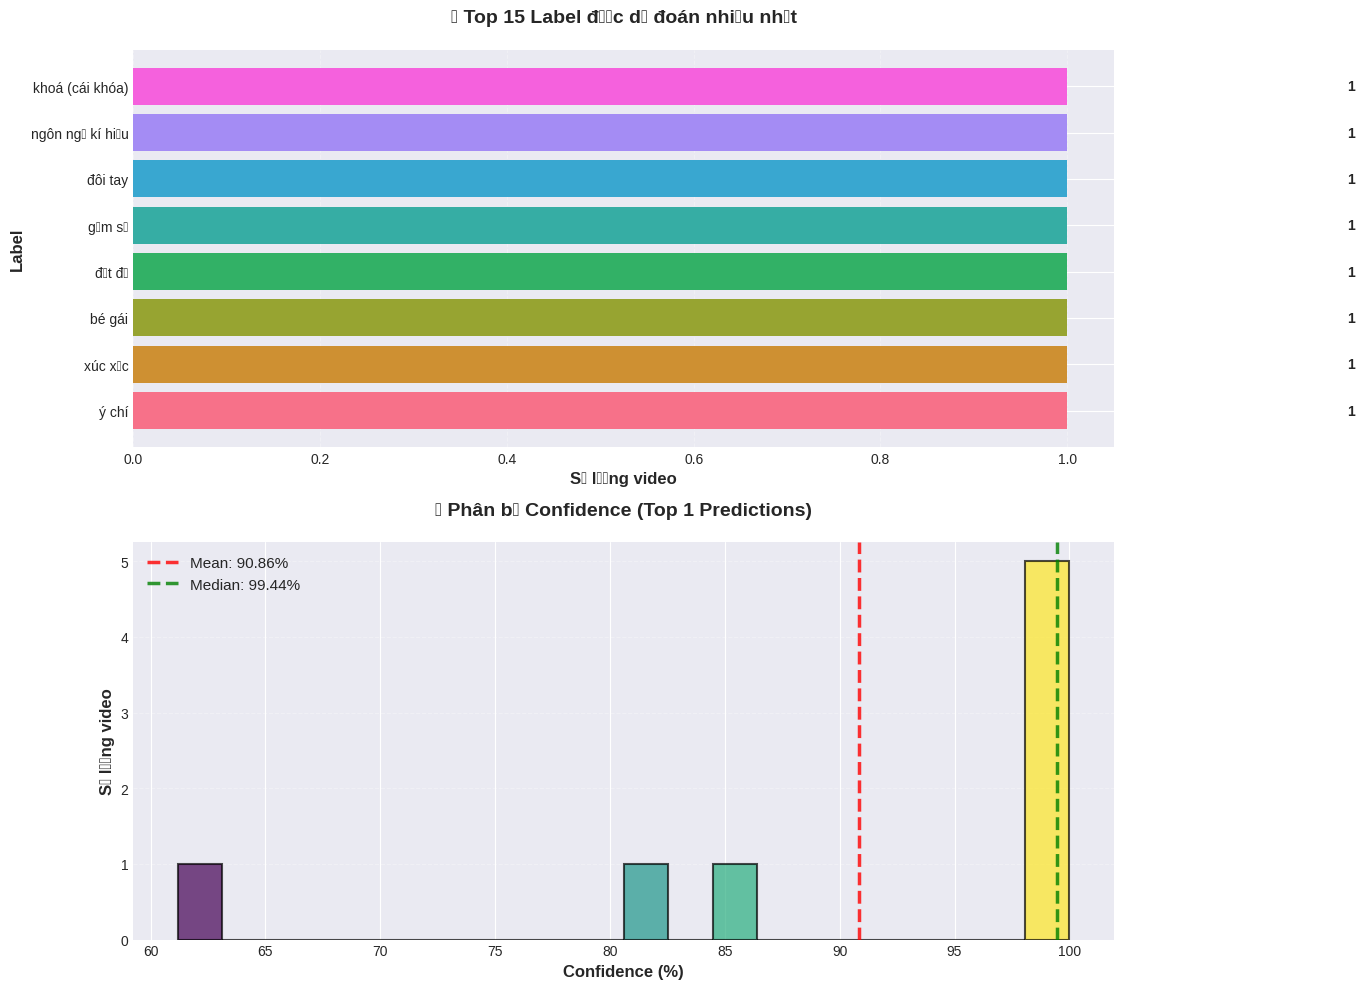

✅ Biểu đồ đã được tạo!


In [ ]:
if len(video_files) > 0 and len(results_list) > 0 and len(df_valid) > 0:
    print("📊 Biểu đồ phân bố chi tiết:")
    print("=" * 80)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Biểu đồ 1: Top 15 label được dự đoán nhiều nhất
    top_labels = df_valid['top1_label'].value_counts().head(15)
    ax1 = axes[0]
    colors1 = sns.color_palette("husl", len(top_labels))
    bars1 = ax1.barh(range(len(top_labels)), top_labels.values, color=colors1)
    ax1.set_yticks(range(len(top_labels)))
    ax1.set_yticklabels(top_labels.index, fontsize=10)
    ax1.set_xlabel('Số lượng video', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Label', fontsize=12, fontweight='bold')
    ax1.set_title('🏆 Top 15 Label được dự đoán nhiều nhất', fontsize=14, fontweight='bold', pad=20)

    # Thêm giá trị vào mỗi cột
    for i, (bar, v) in enumerate(zip(bars1, top_labels.values)):
        ax1.text(v + 0.3, i, str(v), va='center', fontsize=10, fontweight='bold')

    ax1.grid(axis='x', alpha=0.3, linestyle='--')

    # Biểu đồ 2: Phân bố confidence
    ax2 = axes[1]
    n, bins, patches = ax2.hist(df_valid['top1_confidence'], bins=20, color='skyblue',
                                edgecolor='black', alpha=0.7, linewidth=1.5)

    # Tô màu gradient cho histogram
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    col = bin_centers - min(bin_centers)
    col /= max(col)
    for c, p in zip(col, patches):
        plt.setp(p, 'facecolor', plt.cm.viridis(c))

    mean_val = df_valid['top1_confidence'].mean()
    median_val = df_valid['top1_confidence'].median()

    ax2.axvline(mean_val, color='red', linestyle='--',
               linewidth=2.5, label=f"Mean: {mean_val:.2f}%", alpha=0.8)
    ax2.axvline(median_val, color='green', linestyle='--',
               linewidth=2.5, label=f"Median: {median_val:.2f}%", alpha=0.8)

    ax2.set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Số lượng video', fontsize=12, fontweight='bold')
    ax2.set_title('📈 Phân bố Confidence (Top 1 Predictions)', fontsize=14, fontweight='bold', pad=20)
    ax2.legend(fontsize=11, loc='upper left')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

    print("✅ Biểu đồ đã được tạo!")
    print("=" * 80)

## 13. Hiển thị chi tiết một số video

In [ ]:
if len(video_files) > 0 and len(results_list) > 0 and len(df_valid) > 0:
    print("=" * 80)
    print("🔍 CHI TIẾT VIDEO MẪU".center(80))
    print("=" * 80)

    # Chọn video để hiển thị chi tiết
    num_samples = min(3, len(df_valid))  # Giảm từ 5 xuống 3 để gọn hơn
    sample_videos = df_valid.sample(n=num_samples, random_state=42)

    print(f"\n📌 Hiển thị chi tiết {num_samples} video ngẫu nhiên:\n")

    for idx, (_, row) in enumerate(sample_videos.iterrows(), 1):
        print(f"{'─' * 80}")
        print(f"📹 Video {idx}: {row['video_name']}")
        print(f"{'─' * 80}")

        # Tạo list top 5
        top5 = [
            (row['top1_label'], row['top1_confidence']),
            (row['top2_label'], row['top2_confidence']),
            (row['top3_label'], row['top3_confidence']),
            (row['top4_label'], row['top4_confidence']),
            (row['top5_label'], row['top5_confidence']),
        ]

        # In ra top 5 với format đẹp
        for i, (label, conf) in enumerate(top5, 1):
            if label:  # Chỉ in nếu có label
                marker = "🏆" if i == 1 else "  "
                # Thêm thông tin video training
                videos = label_to_videos.get(label, [])
                video_info = f" [{', '.join(videos)}]" if videos else ""
                bar = "█" * int(conf / 5)  # Simple bar
                print(f"{marker} {i}. {label:<20} {bar:<20} {conf:>6.2f}%{video_info}")
        print()

    print("=" * 80)

                              🔍 CHI TIẾT VIDEO MẪU                              

📌 Hiển thị chi tiết 3 video ngẫu nhiên:

────────────────────────────────────────────────────────────────────────────────
📹 Video 1: Bản sao của W04013.mp4
────────────────────────────────────────────────────────────────────────────────
🏆 1. xúc xắc              ███████████████████   99.72% [W04013.mp4]
   2. giai đoạn                                   0.24% [W01423.mp4]
   3. gương mẫu                                   0.03% [W01525.mp4]
   4. từ đồng âm                                  0.00% [W03711.mp4]
   5. dầu mỏ                                      0.00% [W00997.mp4]

────────────────────────────────────────────────────────────────────────────────
📹 Video 2: Bản sao của W03962B.mp4
────────────────────────────────────────────────────────────────────────────────
🏆 1. đôi tay              ████████████████      81.30% [W01274.mp4]
   2. đôi chân             ███                   18.50% [W01273.mp4

## 14. Tìm video có confidence cao nhất và thấp nhất

                   🎯 SO SÁNH CONFIDENCE CAO NHẤT & THẤP NHẤT                    

🏆 CONFIDENCE CAO NHẤT:
────────────────────────────────────────────────────────────────────────────────
  📹 Video:      Bản sao của W04035.mp4
  🎯 Prediction: ý chí
  📊 Confidence: 100.00%

⚠️  CONFIDENCE THẤP NHẤT:
────────────────────────────────────────────────────────────────────────────────
  📹 Video:      Bản sao của W04057T.mp4
  🎯 Prediction: gốm sứ
  📊 Confidence: 61.19%

📊 Biểu đồ so sánh Top 5:


/tmp/ipython-input-4285154885.py:84: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-4285154885.py:84: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-4285154885.py:84: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-4285154885.py:84: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-4285154885.py:84: UserWarning: Glyph 7844 (\N{LATIN CAPITAL LETTER A WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-4285154885.py:84: UserWarning: Glyph 777 (\N{COMBINING HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-428515

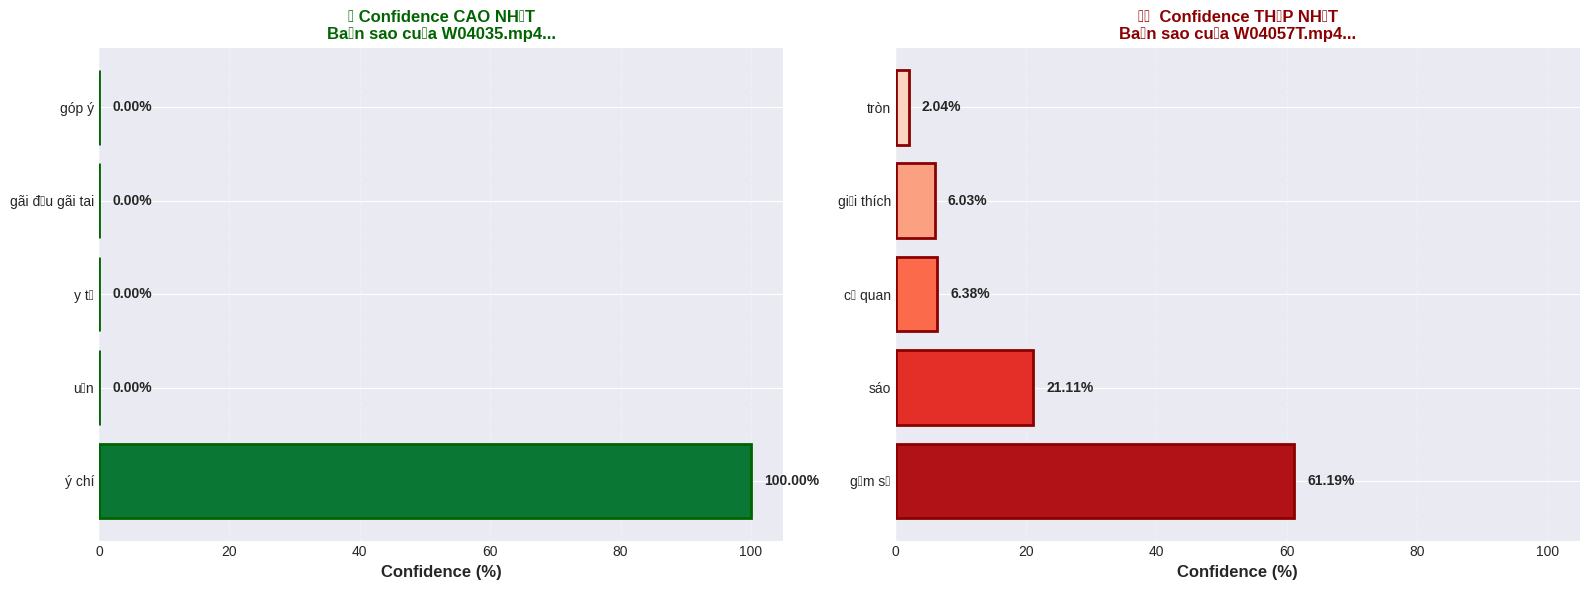

✅ Biểu đồ so sánh đã được tạo!


In [ ]:
if len(video_files) > 0 and len(results_list) > 0 and len(df_valid) > 0:
    print("=" * 80)
    print("🎯 SO SÁNH CONFIDENCE CAO NHẤT & THẤP NHẤT".center(80))
    print("=" * 80)

    # Video có confidence cao nhất
    max_conf_idx = df_valid['top1_confidence'].idxmax()
    max_conf_video = df_valid.loc[max_conf_idx]

    # Video có confidence thấp nhất
    min_conf_idx = df_valid['top1_confidence'].idxmin()
    min_conf_video = df_valid.loc[min_conf_idx]

    print("\n🏆 CONFIDENCE CAO NHẤT:")
    print(f"{'─' * 80}")
    print(f"  📹 Video:      {max_conf_video['video_name']}")
    print(f"  🎯 Prediction: {max_conf_video['top1_label']}")
    print(f"  📊 Confidence: {max_conf_video['top1_confidence']:.2f}%")

    print("\n⚠️  CONFIDENCE THẤP NHẤT:")
    print(f"{'─' * 80}")
    print(f"  📹 Video:      {min_conf_video['video_name']}")
    print(f"  🎯 Prediction: {min_conf_video['top1_label']}")
    print(f"  📊 Confidence: {min_conf_video['top1_confidence']:.2f}%")

    # Vẽ biểu đồ so sánh
    print("\n📊 Biểu đồ so sánh Top 5:")
    print("=" * 80)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Top 5 của video có confidence cao nhất
    max_top5 = [
        (max_conf_video['top1_label'], max_conf_video['top1_confidence']),
        (max_conf_video['top2_label'], max_conf_video['top2_confidence']),
        (max_conf_video['top3_label'], max_conf_video['top3_confidence']),
        (max_conf_video['top4_label'], max_conf_video['top4_confidence']),
        (max_conf_video['top5_label'], max_conf_video['top5_confidence']),
    ]
    max_top5_valid = [(label, conf) for label, conf in max_top5 if label]

    labels_max = [item[0] for item in max_top5_valid]
    confs_max = [item[1] for item in max_top5_valid]
    colors_max = sns.color_palette("Greens_r", len(labels_max))

    bars_max = axes[0].barh(range(len(labels_max)), confs_max, color=colors_max, edgecolor='darkgreen', linewidth=2)
    axes[0].set_yticks(range(len(labels_max)))
    axes[0].set_yticklabels(labels_max, fontsize=10)
    axes[0].set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'🏆 Confidence CAO NHẤT\n{max_conf_video["video_name"][:30]}...',
                     fontsize=12, fontweight='bold', color='darkgreen')
    axes[0].set_xlim(0, 105)
    axes[0].grid(axis='x', alpha=0.3, linestyle='--')

    for i, (bar, conf) in enumerate(zip(bars_max, confs_max)):
        axes[0].text(conf + 2, i, f'{conf:.2f}%', va='center', fontsize=10, fontweight='bold')

    # Top 5 của video có confidence thấp nhất
    min_top5 = [
        (min_conf_video['top1_label'], min_conf_video['top1_confidence']),
        (min_conf_video['top2_label'], min_conf_video['top2_confidence']),
        (min_conf_video['top3_label'], min_conf_video['top3_confidence']),
        (min_conf_video['top4_label'], min_conf_video['top4_confidence']),
        (min_conf_video['top5_label'], min_conf_video['top5_confidence']),
    ]
    min_top5_valid = [(label, conf) for label, conf in min_top5 if label]

    labels_min = [item[0] for item in min_top5_valid]
    confs_min = [item[1] for item in min_top5_valid]
    colors_min = sns.color_palette("Reds_r", len(labels_min))

    bars_min = axes[1].barh(range(len(labels_min)), confs_min, color=colors_min, edgecolor='darkred', linewidth=2)
    axes[1].set_yticks(range(len(labels_min)))
    axes[1].set_yticklabels(labels_min, fontsize=10)
    axes[1].set_xlabel('Confidence (%)', fontsize=12, fontweight='bold')
    axes[1].set_title(f'⚠️  Confidence THẤP NHẤT\n{min_conf_video["video_name"][:30]}...',
                     fontsize=12, fontweight='bold', color='darkred')
    axes[1].set_xlim(0, 105)
    axes[1].grid(axis='x', alpha=0.3, linestyle='--')

    for i, (bar, conf) in enumerate(zip(bars_min, confs_min)):
        axes[1].text(conf + 2, i, f'{conf:.2f}%', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("✅ Biểu đồ so sánh đã được tạo!")
    print("=" * 80)

## 15. Xuất báo cáo tổng kết

In [ ]:
if len(video_files) > 0 and len(results_list) > 0:
    print("\n" + "=" * 80)
    print("📝 BÁO CÁO TỔNG KẾT".center(80))
    print("=" * 80)

    print("\n📊 THÔNG TIN CHUNG:")
    print("─" * 80)
    success_rate = len(df_valid)/len(df_results)*100 if len(df_results) > 0 else 0
    print(f"  {'Tổng số video:':<25} {len(df_results):>5} videos")
    print(f"  {'✓ Thành công:':<25} {len(df_valid):>5} videos ({success_rate:.1f}%)")
    print(f"  {'✗ Lỗi:':<25} {len(df_results) - len(df_valid):>5} videos")

    if len(df_valid) > 0:
        print("\n📈 THỐNG KÊ CONFIDENCE:")
        print("─" * 80)
        print(f"  {'Trung bình:':<25} {df_valid['top1_confidence'].mean():>6.2f}%")
        print(f"  {'Cao nhất:':<25} {df_valid['top1_confidence'].max():>6.2f}%")
        print(f"  {'Thấp nhất:':<25} {df_valid['top1_confidence'].min():>6.2f}%")
        print(f"  {'Trung vị:':<25} {df_valid['top1_confidence'].median():>6.2f}%")
        print(f"  {'Độ lệch chuẩn:':<25} {df_valid['top1_confidence'].std():>6.2f}%")

        print("\n🏆 TOP 5 LABEL PHỔ BIẾN NHẤT:")
        print("─" * 80)
        top5_labels = df_valid['top1_label'].value_counts().head(5)
        for i, (label, count) in enumerate(top5_labels.items(), 1):
            percentage = count/len(df_valid)*100
            print(f"  {i}. {label:<25} {count:>3} videos ({percentage:.1f}%)")

        print("\n💾 FILES ĐÃ LƯU:")
        print("─" * 80)
        output_csv = os.path.join(BASE_PATH, 'test_results.csv')
        print(f"  📄 {output_csv}")

        print("\n💡 GỢI Ý DEBUG:")
        print("─" * 80)
        if df_valid['top1_confidence'].mean() < 50:
            print("  ⚠️  Confidence trung bình thấp (<50%) - Kiểm tra chất lượng video test")
        if len(df_results) - len(df_valid) > 0:
            print(f"  ⚠️  Có {len(df_results) - len(df_valid)} video lỗi - Kiểm tra format/nội dung video")
        if len(top5_labels) < 5:
            print(f"  ℹ️  Chỉ có {len(top5_labels)} label khác nhau - Dataset test hạn chế")

    print("\n" + "=" * 80)
    print("✅ HOÀN THÀNH TESTING!".center(80))
    print("=" * 80)


                               📝 BÁO CÁO TỔNG KẾT                               

📊 THÔNG TIN CHUNG:
────────────────────────────────────────────────────────────────────────────────
  Tổng số video:                8 videos
  ✓ Thành công:                 8 videos (100.0%)
  ✗ Lỗi:                        0 videos

📈 THỐNG KÊ CONFIDENCE:
────────────────────────────────────────────────────────────────────────────────
  Trung bình:                90.86%
  Cao nhất:                 100.00%
  Thấp nhất:                 61.19%
  Trung vị:                  99.44%
  Độ lệch chuẩn:             14.08%

🏆 TOP 5 LABEL PHỔ BIẾN NHẤT:
────────────────────────────────────────────────────────────────────────────────
  1. ý chí                       1 videos (12.5%)
  2. xúc xắc                     1 videos (12.5%)
  3. bé gái                      1 videos (12.5%)
  4. đắt đỏ                      1 videos (12.5%)
  5. gốm sứ                      1 videos (12.5%)

💾 FILES ĐÃ LƯU:
──────────────────────

Kiem tra frame

In [5]:
import cv2
import os

folder = "/content/drive/MyDrive/VSL_Data/Phuong/Dataset/Videos/"

# Lặp qua toàn bộ file trong thư mục
for filename in os.listdir(folder):
    if filename.lower().endswith(('.mp4', '.mov', '.avi', '.mkv')):
        video_path = os.path.join(folder, filename)
        cap = cv2.VideoCapture(video_path)

        if not cap.isOpened():
            print(f"Không mở được video: {filename}")
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        duration = total_frames / fps if fps > 0 else 0

        print(f"\n=== {filename} ===")
        print(f"Frames: {total_frames}")
        print(f"FPS: {fps}")
        print(f"Duration (s): {duration:.2f}")

        cap.release()



=== D0003.mp4 ===
Frames: 125
FPS: 29.97002997002997
Duration (s): 4.17

=== D0001B.mp4 ===
Frames: 130
FPS: 29.97002997002997
Duration (s): 4.34

=== D0001N.mp4 ===
Frames: 133
FPS: 29.97002997002997
Duration (s): 4.44

=== D0001T.mp4 ===
Frames: 133
FPS: 29.97002997002997
Duration (s): 4.44

=== D0005B.mp4 ===
Frames: 184
FPS: 29.97002997002997
Duration (s): 6.14

=== D0005N.mp4 ===
Frames: 213
FPS: 29.97002997002997
Duration (s): 7.11

=== D0002.mp4 ===
Frames: 147
FPS: 23.976023976023978
Duration (s): 6.13

=== D0005T.mp4 ===
Frames: 213
FPS: 29.97002997002997
Duration (s): 7.11

=== D0197.mp4 ===
Frames: 161
FPS: 29.97002997002997
Duration (s): 5.37

=== D0004.mp4 ===
Frames: 125
FPS: 29.97002997002997
Duration (s): 4.17

=== D0009.mp4 ===
Frames: 99
FPS: 29.97002997002997
Duration (s): 3.30

=== D0010.mp4 ===
Frames: 126
FPS: 29.97002997002997
Duration (s): 4.20

=== D0006.mp4 ===
Frames: 115
FPS: 29.97002997002997
Duration (s): 3.84

=== D0007.mp4 ===
Frames: 150
FPS: 29.970029